In [1]:
# ─────────────────────────────────────────────────────────────
# Exploratory Analysis Setup
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path


# ─────────────────────────────────────────────────────────────
# Chart Style Settings
# ─────────────────────────────────────────────────────────────
# These settings make the visuals cleaner and easier to read.
# Instead of repeating the same chart formatting in every plot,I set some default options once at the beginning of the notebook.

plt.rcParams["figure.figsize"] = (12, 5)      # Default chart size: wide enough for labels and comparisons
plt.rcParams["axes.spines.top"] = False      # Remove the top border from charts for a cleaner look
plt.rcParams["axes.spines.right"] = False    # Remove the right border from charts for a cleaner look

sns.set_palette("Blues_d")


# ─────────────────────────────────────────────────────────────
# Project Paths
# ─────────────────────────────────────────────────────────────


PROCESSED = Path("../data/processed")


# ─────────────────────────────────────────────────────────────
# Confirmation Message
# ─────────────────────────────────────────────────────────────

print("Libraries loaded")

Libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────
# Load all three datasets
# ─────────────────────────────────────────────────────────────
df_adm  = pd.read_csv(PROCESSED / "admissions_clean.csv", parse_dates=["date_of_admission", "discharge_date"])
df_er   = pd.read_csv(PROCESSED / "er_visits_clean.csv",  parse_dates=["visit_datetime"])
df_cihi = pd.read_csv(PROCESSED / "cihi_wait_times_clean.csv")

print(f"Admissions : {len(df_adm):,} rows")
print(f"ER visits  : {len(df_er):,} rows")
print(f"CIHI       : {len(df_cihi):,} rows")

Admissions : 55,392 rows
ER visits  : 5,000 rows
CIHI       : 14,476 rows


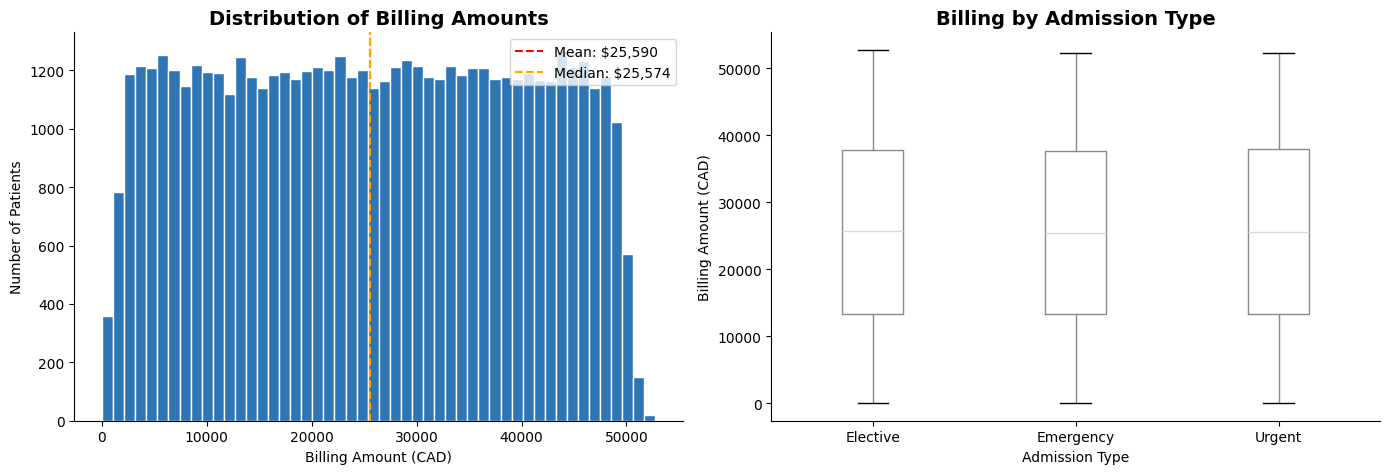

Mean   : $25,590.08
Median : $25,573.83
Std Dev: $14,178.66
Skew   : 0.000


In [3]:
# ─────────────────────────────────────────────────────────────
# Admissions: Billing Distribution
# ─────────────────────────────────────────────────────────────
# Here, I explore how billing amounts are distributed across hospital admissions.
#
# I use two visuals:
# 1. A histogram to understand the overall shape of billing amounts.
# 2. A boxplot to compare billing amounts across admission types.


# Make a clean copy of the billing column and remove missing values so the charts and statistics are not affected by null records.
billing = df_adm["billing_amount"].dropna()

# Create one figure with two charts side by side.
# axes[0] will be used for the histogram.
# axes[1] will be used for the boxplot.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ─────────────────────────────────────────────────────────────
# Histogram: Overall Billing Distribution
# ─────────────────────────────────────────────────────────────
# A histogram shows how often different billing amounts appear.
# This helps identify whether billing is normally distributed, skewed, or affected by extreme values.

axes[0].hist(
    billing,
    bins=50,
    color="#2E75B6",
    edgecolor="white"
)

axes[0].set_title(
    "Distribution of Billing Amounts",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Billing Amount (CAD)")
axes[0].set_ylabel("Number of Patients")

# Add a vertical line for the mean.
# The mean is sensitive to very high or very low billing amounts.
axes[0].axvline(
    billing.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: ${billing.mean():,.0f}"
)

# Add a vertical line for the median.
# The median is usually more stable when the data is skewed.
axes[0].axvline(
    billing.median(),
    color="orange",
    linestyle="--",
    label=f"Median: ${billing.median():,.0f}"
)

axes[0].legend()


# ─────────────────────────────────────────────────────────────
# Boxplot: Billing by Admission Type
# ─────────────────────────────────────────────────────────────
# A boxplot compares billing amounts across admission types.
# It shows the median, spread, and possible outliers for each group.
#


df_adm.boxplot(
    column="billing_amount",
    by="admission_type",
    ax=axes[1],
    grid=False
)

axes[1].set_title(
    "Billing by Admission Type",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Admission Type")
axes[1].set_ylabel("Billing Amount (CAD)")

# Remove the automatic pandas boxplot title so the figure looks cleaner.
fig.suptitle("")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# Summary Statistics
# ─────────────────────────────────────────────────────────────
# These statistics give numerical support to what we see in the charts.
#
# Mean: average billing amount
# Median: middle billing amount
# Standard deviation: how spread out the billing values are
# Skew: whether the distribution leans left or right
#
# Skew interpretation:
# - close to 0  : approximately symmetric
# - positive    : right-skewed, with some high billing values
# - negative    : left-skewed, with some low billing values

print(f"Mean   : ${billing.mean():,.2f}")
print(f"Median : ${billing.median():,.2f}")
print(f"Std Dev: ${billing.std():,.2f}")
print(f"Skew   : {billing.skew():.3f}")


The billing amount distribution does not appear to be normally distributed. A normal distribution would usually have a bell-shaped pattern, where most values are concentrated around the center. In this chart, billing amounts appear to be spread fairly evenly across most of the range, which makes the distribution look closer to a uniform distribution.

The mean billing amount is approximately $25,590, while the median is approximately $25,574. Since the mean and median are almost the same, this suggests that the distribution is fairly symmetric and does not show a strong right or left skew.

Admission type does not appear to have a strong visual effect on billing amount. The boxplots for Elective, Emergency, and Urgent admissions look very similar. Their median values, ranges, and spreads are close to each other, which suggests that billing amounts are distributed similarly across the three admission types.

In real healthcare billing data, I would usually expect a right-skewed distribution. Most patients would likely have moderate costs, while a smaller number of complex cases would have very high costs due to longer hospital stays, emergency treatment, surgery, intensive care, or additional procedures. I would also expect emergency and urgent admissions to show more billing variation than elective admissions.

Because this dataset looks very balanced and clean, it may be simplified or synthetic. In real hospital data, billing amounts usually contain stronger outliers, more variation, and clearer cost differences between patient groups.

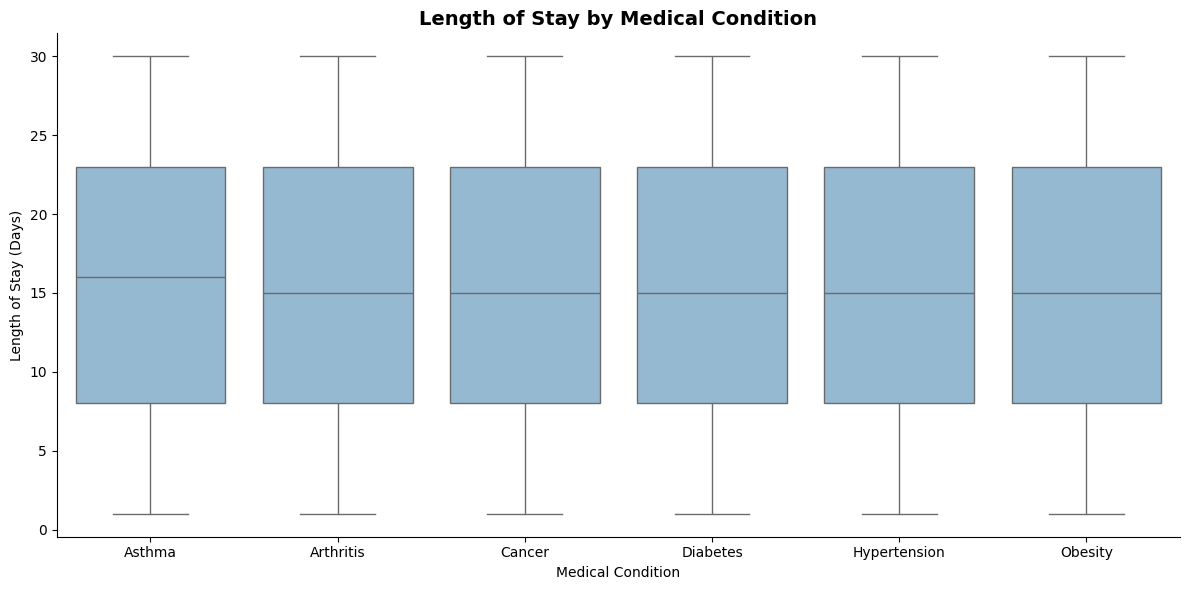

                   median  mean  std
medical_condition                   
Asthma               16.0  15.7  8.7
Arthritis            15.0  15.5  8.6
Cancer               15.0  15.5  8.7
Diabetes             15.0  15.4  8.7
Hypertension         15.0  15.5  8.6
Obesity              15.0  15.5  8.7


In [4]:
# ─────────────────────────────────────────────────────────────
# Admissions: Length of Stay by Medical Condition
# ─────────────────────────────────────────────────────────────
# Here, I analyze how long patients stay in the hospital based on their medical condition.
#
# Length of Stay (LOS) is an important healthcare metric because it can reflect patient complexity, resource usage, hospital capacity pressure, and potential cost differences between medical groups.

fig, ax = plt.subplots(figsize=(12, 6))


# ─────────────────────────────────────────────────────────────
# Order Medical Conditions by Median Length of Stay
# ─────────────────────────────────────────────────────────────
# Before creating the boxplot, I order the medical conditions by their median length of stay.
#
# I use the median instead of the mean because LOS can be affected by outliers. 
# For example, a few patients with very long stays can pull the mean upward, while the median gives a more stable view of the typical patient stay.

order = (
    df_adm
    .groupby("medical_condition")["length_of_stay_days"]
    .median()
    .sort_values(ascending=False)
    .index
)


# ─────────────────────────────────────────────────────────────
# Boxplot: Length of Stay by Medical Condition
# ─────────────────────────────────────────────────────────────


sns.boxplot(
    data=df_adm,
    x="medical_condition",
    y="length_of_stay_days",
    order=order,
    ax=ax
)


# ─────────────────────────────────────────────────────────────
# Chart Labels
# ─────────────────────────────────────────────────────────────

ax.set_title(
    "Length of Stay by Medical Condition",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Medical Condition")
ax.set_ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# Summary Statistics by Medical Condition
# ─────────────────────────────────────────────────────────────
# After the visual comparison, I calculate summary statistics for each medical condition.
#
# median : typical length of stay
# mean   : average length of stay
# std    : variation in length of stay
#

los_summary = (
    df_adm
    .groupby("medical_condition")["length_of_stay_days"]
    .agg(["median", "mean", "std"])
    .round(1)
    .sort_values("median", ascending=False)
)

print(los_summary)


The boxplot shows that length of stay is very similar across all medical conditions. Most conditions have a median length of stay of about 15 days, with Asthma slightly higher at 16 days. However, this difference is very small and does not suggest a strong practical difference between conditions.

The mean values are also very close across all groups, ranging from approximately 15.4 to 15.7 days. This confirms that the average hospital stay is almost the same regardless of medical condition in this dataset.

The standard deviation is also nearly identical across conditions, around 8.6 to 8.7 days. This means that the amount of variation in length of stay is similar for each condition.

Based on the visual comparison and summary statistics, medical condition does not appear to strongly affect length of stay in this dataset. The distributions, medians, means, and spreads are almost identical across groups.

In real healthcare data, I would usually expect more variation between conditions. Some conditions, such as cancer, complex diabetes cases, or severe respiratory cases, may require longer stays due to treatment complexity, complications, or recovery time. Since the patterns here are very balanced, the dataset may be simplified or synthetic.


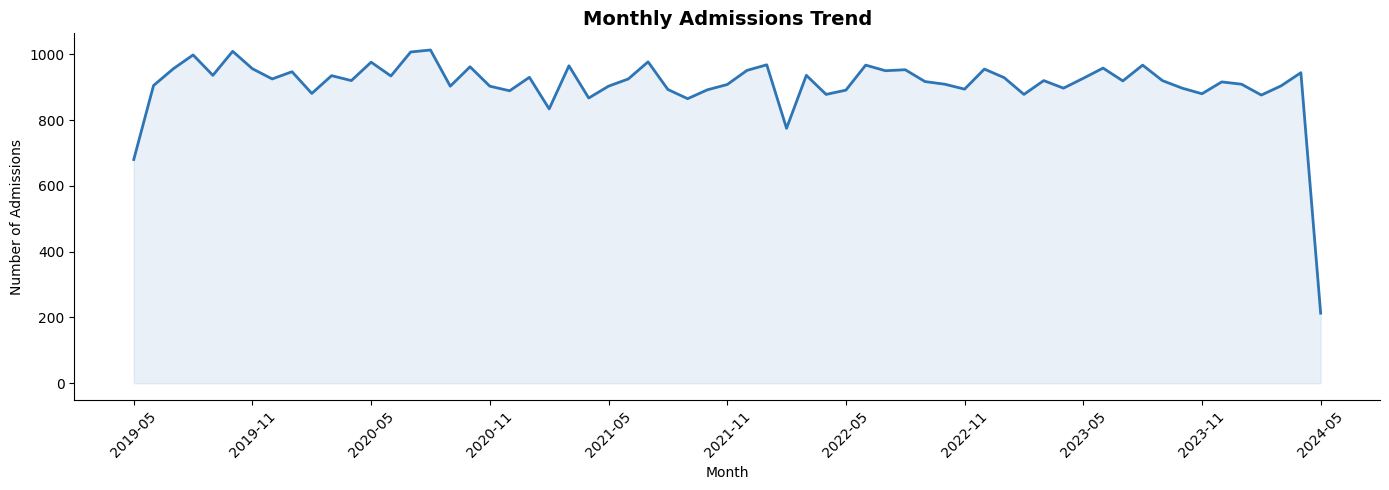

Peak month  : 2020-08 (1,013)
Lowest month: 2024-05 (213)


In [5]:
# ─────────────────────────────────────────────────────────────
# Admissions: Monthly Trend
# ─────────────────────────────────────────────────────────────
# Here, I analyze how hospital admissions change over time.
#
# The goal is to identify monthly patterns, peak admission months, and low-demand periods. 


# ─────────────────────────────────────────────────────────────
# Create Admission Month
# ─────────────────────────────────────────────────────────────
# date_of_admission is already parsed as a datetime column when the dataset was loaded. 
# Here, I convert it to a monthly period such as:
# 2023-01, 2023-02, 2023-03
#
# Using monthly periods makes it easier to group admissions by month instead of analyzing each individual date.

df_adm["admission_month"] = df_adm["date_of_admission"].dt.to_period("M")


# ─────────────────────────────────────────────────────────────
# Count Admissions per Month
# ─────────────────────────────────────────────────────────────
# I group the admissions by month and count how many records appear in each month.


monthly = (
    df_adm
    .groupby("admission_month")
    .size() #counts the number of rows per month
    .reset_index(name="admissions")
)


# Convert the monthly period to text so it displays cleanly on the chart.
monthly["admission_month"] = monthly["admission_month"].astype(str)


# ─────────────────────────────────────────────────────────────
# Line Chart: Monthly Admissions Trend
# ─────────────────────────────────────────────────────────────
# I Chose the line chart here because it is useful for analyzing change over time.
# It helps show whether admissions are stable, increasing, decreasing, or fluctuating month by month.

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly["admission_month"],
    monthly["admissions"],
    color="#2E75B6",
    linewidth=2
)



ax.fill_between(
    range(len(monthly)),
    monthly["admissions"],
    alpha=0.1,
    color="#2E75B6"
)


# Show only every 6th month on the x-axis.
# This prevents the chart from becoming crowded if the dataset covers many months.
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels(monthly["admission_month"][::6], rotation=45)


# Chart labels
ax.set_title(
    "Monthly Admissions Trend",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Admissions")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# Peak and Lowest Admission Months
# ─────────────────────────────────────────────────────────────
# These lines identify the month with the highest number of admissionsand the month with the lowest number of admissions.
#


peak_month = monthly.loc[monthly["admissions"].idxmax(), "admission_month"]
peak_count = monthly["admissions"].max()

lowest_month = monthly.loc[monthly["admissions"].idxmin(), "admission_month"]
lowest_count = monthly["admissions"].min()

print(f"Peak month  : {peak_month} ({peak_count:,})")
print(f"Lowest month: {lowest_month} ({lowest_count:,})")


The monthly admissions trend appears relatively stable across most of the observed period. From 2019 to early 2024, most months have approximately 850 to 1,000 admissions, which suggests that hospital admission volume is fairly consistent over time.

The peak month was **2020-08**, with **1,013 admissions**. However, this value is not dramatically higher than the surrounding months, so it does not appear to represent a major spike or unusual event.

The lowest month was **2024-05**, with **213 admissions**. This month is much lower than the rest of the trend and appears at the end of the dataset. Because of that, it is likely a partial or incomplete month rather than a true drop in hospital demand. This value should be interpreted carefully and may need to be excluded from trend conclusions.

Overall, there is no strong upward or downward trend in admissions. The data shows normal month-to-month fluctuation, but admissions remain broadly stable across the full period.

In real healthcare data, I would expect some seasonal variation, especially during winter months when respiratory illnesses and other seasonal conditions may increase hospital demand. I would also expect sudden spikes or drops to require further investigation, because they could be caused by incomplete data, reporting changes, policy changes, or unusual healthcare events.

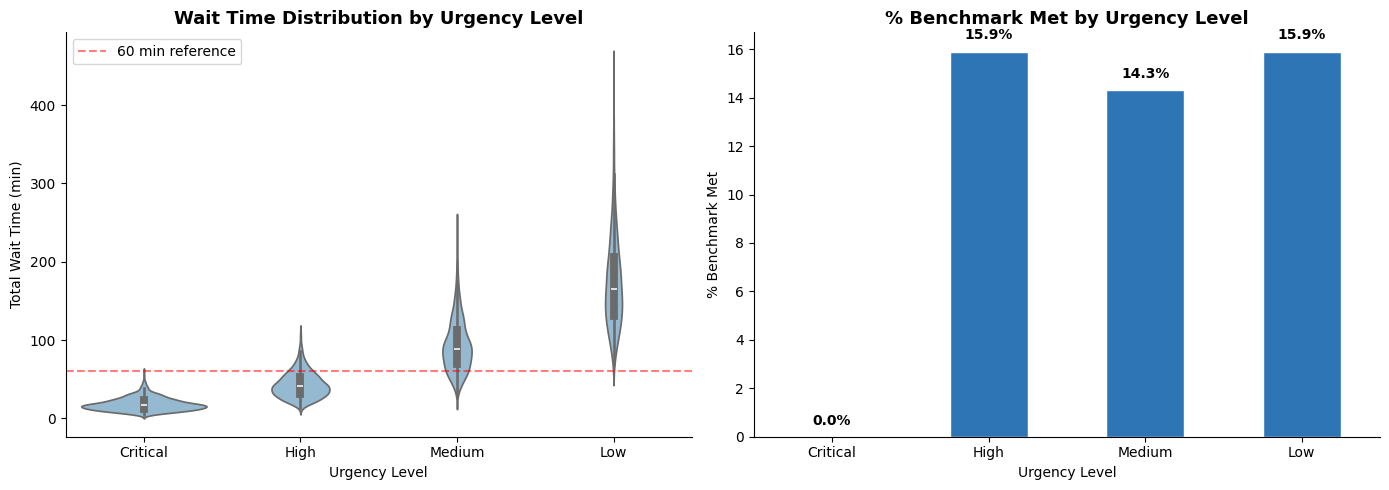

                mean  median   std
urgency_level                     
Critical        18.4    17.0   8.1
High            43.2    41.0  16.3
Medium          93.7    89.0  33.8
Low            173.5   165.0  57.0


In [6]:
# ─────────────────────────────────────────────────────────────
# ER Analysis: Wait Time Distribution
# ─────────────────────────────────────────────────────────────
# In this section, I analyze emergency room wait times by urgency level.
#
# The goal is to check whether more urgent patients are seen faster and whether each urgency group is meeting the expected wait-time benchmark.



fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ─────────────────────────────────────────────────────────────
# Violin Plot: Wait Time Distribution by Urgency Level
# ─────────────────────────────────────────────────────────────
# A violin plot shows the full distribution shape of wait times.
# It is more detailed than a boxplot because it shows where wait times are more concentrated within each urgency level.
#
# The order is set manually so the chart follows clinical priority:
# Critical -> High -> Medium -> Low

urgency_order = ["Critical", "High", "Medium", "Low"]

sns.violinplot(
    data=df_er,
    x="urgency_level",
    y="total_wait_time_min",
    order=urgency_order,
    ax=axes[0]
)

axes[0].set_title(
    "Wait Time Distribution by Urgency Level",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Urgency Level")
axes[0].set_ylabel("Total Wait Time (min)")


# Add a 60-minute reference line.
# This helps compare wait times against a simple benchmark threshold.

axes[0].axhline(
    60,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="60 min reference"
)

axes[0].legend()


# ─────────────────────────────────────────────────────────────
# Benchmark Met Percentage by Urgency Level
# ─────────────────────────────────────────────────────────────
# benchmark_met is expected to be a True/False or 1/0 column.
#
# Taking the mean of a Boolean column gives the proportion of records where the benchmark was met.
#


benchmark = (
    df_er
    .groupby("urgency_level")["benchmark_met"]
    .mean()
    .mul(100)
    .round(1)
    .reindex(urgency_order)
)


# Create a bar chart to compare benchmark performance across urgency levels.
benchmark.plot(
    kind="bar",
    ax=axes[1],
    color="#2E75B6",
    edgecolor="white"
)

axes[1].set_title(
    "% Benchmark Met by Urgency Level",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Urgency Level")
axes[1].set_ylabel("% Benchmark Met")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)


# Add percentage labels above each bar so the chart is easier to read.
for i, v in enumerate(benchmark):
    axes[1].text(
        i,
        v + 0.5,
        f"{v}%",
        ha="center",
        fontweight="bold"
    )


plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# Summary Statistics by Urgency Level
# ─────────────────────────────────────────────────────────────
# These statistics support the visuals with actual numbers.
#
# mean   : average wait time
# median : typical wait time
# std    : variation in wait times
#


wait_time_summary = (
    df_er
    .groupby("urgency_level")["total_wait_time_min"]
    .agg(["mean", "median", "std"])
    .round(1)
    .reindex(urgency_order)
)

print(wait_time_summary)


The ER wait time distribution shows a clear and clinically logical pattern across urgency levels. Critical patients have the shortest wait times, followed by High, Medium, and Low urgency patients. This suggests that the triage process is prioritizing more urgent patients appropriately.

The median wait time increases from **17 minutes** for Critical cases to **41 minutes** for High, **89 minutes** for Medium, and **165 minutes** for Low urgency cases. The mean values follow the same pattern, confirming that lower-urgency patients generally wait longer.

The 60-minute reference line also highlights this difference. Critical and High urgency visits are mostly below or near the 60-minute line, while Medium and Low urgency visits are mostly above it. This indicates that longer waits are concentrated among less urgent cases.

The standard deviation increases as urgency decreases. Critical visits have the lowest variation in wait time, while Low urgency visits have the highest variation. This suggests that lower-urgency patients experience more inconsistent wait times, likely because they are more affected by ER crowding and prioritization of higher-acuity patients.

However, the benchmark-met percentages require careful interpretation. Critical cases show **0.0% benchmark met**, even though they have the shortest wait times overall. This may indicate that the benchmark rule for Critical patients is very strict, or that the benchmark logic needs to be reviewed. The benchmark results should therefore be interpreted alongside the actual wait-time distribution rather than in isolation.




In [7]:
# ─────────────────────────────────────────────────────────────
# ER Hypothesis Test: Urban vs Rural Wait Times
# ─────────────────────────────────────────────────────────────
# Question:
# Do urban and rural hospitals have significantly different ER wait times?
#
# H0 (null hypothesis):
# There is no difference in mean ER wait time between urban and rural hospitals.
#
# H1 (alternative hypothesis):
# Urban and rural hospitals have different mean ER wait times.
#
# Test:
# Two-sample independent t-test, two-sided.
#
# Alpha:
# 0.05


# ─────────────────────────────────────────────────────────────
# Prepare Urban and Rural Groups
# ─────────────────────────────────────────────────────────────
# I separate the ER wait-time data into two independent groups:
# Urban hospitals and Rural hospitals.
#
# dropna() removes missing wait-time values so the test only uses valid records.

urban = (
    df_er
    .loc[df_er["region"] == "Urban", "total_wait_time_min"]
    .dropna()
)

rural = (
    df_er
    .loc[df_er["region"] == "Rural", "total_wait_time_min"]
    .dropna()
)


# ─────────────────────────────────────────────────────────────
# Run Two-Sided Independent T-Test
# ─────────────────────────────────────────────────────────────
# This test compares the mean ER wait time between Urban and Rural hospitals.
#
# equal_var=False applies Welch's t-test, which is safer when the two groups may have different sample sizes or different variances.

t_stat, p_value = stats.ttest_ind(
    urban,
    rural,
    equal_var=False,
    alternative="two-sided"
)


# ─────────────────────────────────────────────────────────────
# Print Results
# ─────────────────────────────────────────────────────────────
# The means show the practical difference between the two groups.
# The p-value tells us whether the difference is statistically significant.

alpha = 0.05

print("=== Hypothesis Test: Urban vs Rural ER Wait Times ===")
print(f"Urban mean : {urban.mean():.1f} min  (n={len(urban):,})")
print(f"Rural mean : {rural.mean():.1f} min  (n={len(rural):,})")
print(f"Difference : {urban.mean() - rural.mean():.1f} min")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value    : {p_value:.4f}")
print()

if p_value < alpha:
    print("Result: REJECT the null hypothesis.")
    print("There is a statistically significant difference in mean ER wait times between Urban and Rural hospitals.")
else:
    print("Result: FAIL TO REJECT the null hypothesis.")
    print("There is no statistically significant difference in mean ER wait times between Urban and Rural hospitals.")

=== Hypothesis Test: Urban vs Rural ER Wait Times ===
Urban mean : 82.0 min  (n=3,006)
Rural mean : 81.8 min  (n=1,994)
Difference : 0.2 min
T-statistic: 0.0776
P-value    : 0.9382

Result: FAIL TO REJECT the null hypothesis.
There is no statistically significant difference in mean ER wait times between Urban and Rural hospitals.


The two-sided Welch’s t-test was used to compare average ER wait times between urban and rural hospitals.

The average wait time for urban hospitals was **82.0 minutes**, while the average wait time for rural hospitals was **81.8 minutes**. The difference between the two means was only **0.2 minutes**, which is very small and not practically meaningful.

The test produced a t-statistic of **0.0776** and a p-value of **0.9382**. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

This means that there is no statistically significant difference in average ER wait times between urban and rural hospitals in this dataset.

From a practical perspective, the difference is also negligible. A difference of 0.2 minutes is approximately 12 seconds, which would not be meaningful for hospital operations or patient experience.

Overall, region alone does not appear to explain ER wait time differences in this dataset. Other factors, such as urgency level, patient volume, staffing, time of day, or hospital capacity, may be more important drivers of wait time.

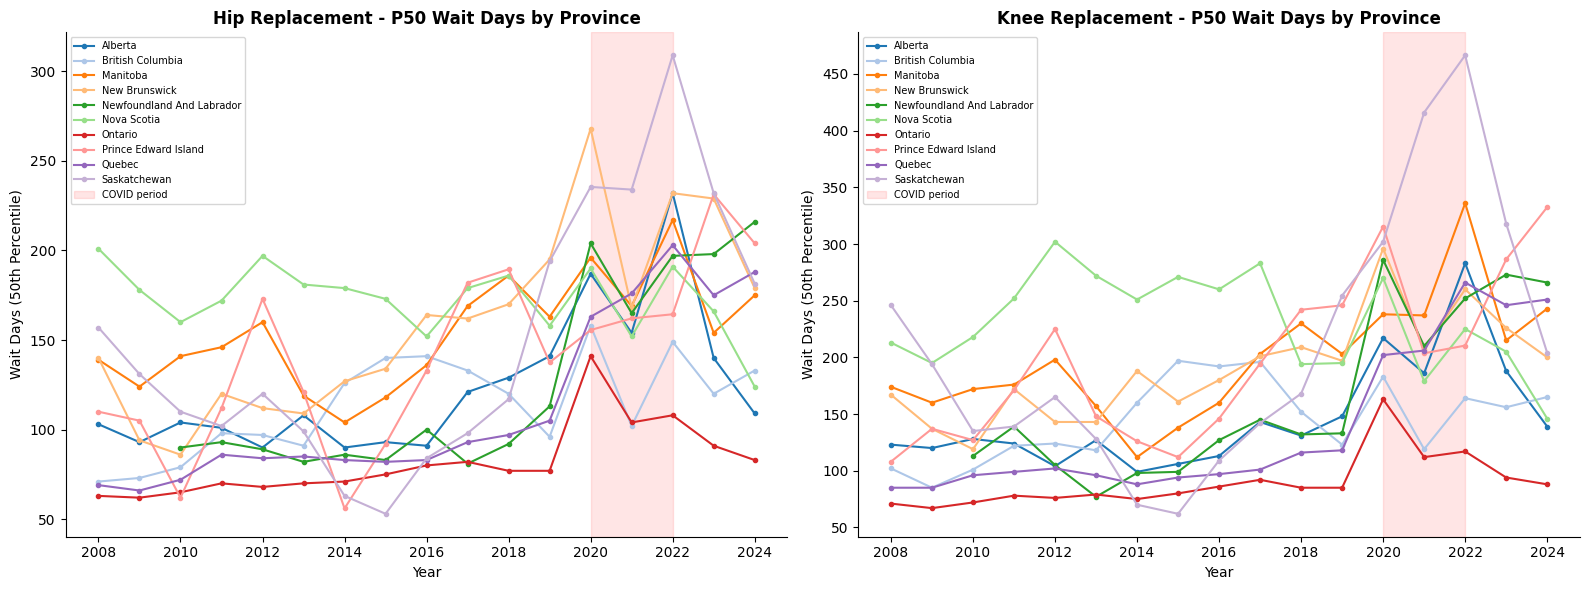

In [9]:
# ─────────────────────────────────────────────────────────────
# CIHI Wait Times: Hip and Knee Replacement Trends
# ─────────────────────────────────────────────────────────────
# In this section, I use the CIHI wait-times dataset to analyze how median wait times changed over time for two common priority procedures:
# hip replacement and knee replacement.
# The goal is to compare provincial trends and see whether wait times increased during or after the COVID period.


# ─────────────────────────────────────────────────────────────
# Filter CIHI Data
# ─────────────────────────────────────────────────────────────
# I keep only the rows needed for this analysis:
#
# 1. Indicator:
#    Hip Replacement and Knee Replacement only.
#
# 2. Metric:
#    50th Percentile, which represents the median wait time.
#    This means 50% of patients waited less than this value and 50% waited more.
#
# 3. Province:
#    Exclude "Canada" because I want to compare provinces individually, not the national aggregate.
#
# 4. Reporting level:
#    Provincial only, to avoid mixing provincial data with regional data.

cihi_plot = df_cihi[
    (df_cihi["indicator"].isin(["Hip Replacement", "Knee Replacement"]))
    & (df_cihi["metric"] == "50th Percentile")
    & (df_cihi["province"] != "Canada")
    & (df_cihi["reporting_level"] == "Provincial")
].copy()


# ─────────────────────────────────────────────────────────────
# Prepare Data for Plotting
# ─────────────────────────────────────────────────────────────
# I convert the year and wait-time columns to numeric values to avoid plotting issues
# if they were imported as text from the CSV file.

cihi_plot["data_year"] = pd.to_numeric(cihi_plot["data_year"], errors="coerce")
cihi_plot["indicator_result"] = pd.to_numeric(cihi_plot["indicator_result"], errors="coerce")

cihi_plot = cihi_plot.dropna(subset=["data_year", "indicator_result"])

cihi_plot = cihi_plot.sort_values(
    ["indicator", "province", "data_year"]
)


# ─────────────────────────────────────────────────────────────
# Create Province Color Mapping
# ─────────────────────────────────────────────────────────────
# I use a categorical color palette so each province gets a distinct color.
# This makes the chart easier to read than using only blue gradients.
#
# The same province keeps the same color in both charts.

provinces = sorted(cihi_plot["province"].unique())

color_palette = plt.cm.tab20.colors

province_colors = {
    province: color_palette[i % len(color_palette)]
    for i, province in enumerate(provinces)
}


# ─────────────────────────────────────────────────────────────
# Create Side-by-Side Trend Charts
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# ─────────────────────────────────────────────────────────────
# Plot Each Procedure by Province
# ─────────────────────────────────────────────────────────────

for ax, procedure in zip(axes, ["Hip Replacement", "Knee Replacement"]):

    # Keep only the current procedure being plotted
    subset = cihi_plot[cihi_plot["indicator"] == procedure]

    # Draw one trend line for each province
    for province, grp in subset.groupby("province"):
        ax.plot(
            grp["data_year"],
            grp["indicator_result"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=province_colors[province],
            label=province
        )

    # Highlight the COVID period to make it easier to see whether wait times changed during or around this period.
    ax.axvspan(
        2020,
        2022,
        alpha=0.1,
        color="red",
        label="COVID period"
    )

    ax.set_title(
        f"{procedure} - P50 Wait Days by Province",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("Wait Days (50th Percentile)")

    # Small legend because there are many provinces
    ax.legend(fontsize=7, loc="upper left")


plt.tight_layout()
plt.show()

For hip replacement, several provinces show noticeable increases in median wait days during the 2020–2022 COVID period. Some provinces exceeded 200 median wait days, with one province reaching above 300 days around 2022. This suggests that hip replacement wait times increased for many provinces during or shortly after the COVID period.

For knee replacement, the increase is even more pronounced. Several provinces show sharp spikes during the COVID period, with one province exceeding 450 median wait days. This indicates that knee replacement procedures experienced larger wait-time pressures and greater variation across provinces compared with hip replacement.

The shaded COVID period provides useful context, but the chart alone does not prove that COVID directly caused the increases. The timing of the spikes aligns with a period when elective procedures were likely affected by reduced surgical capacity and backlog pressures.

Overall, the CIHI trend analysis shows that wait times increased across many provinces during the COVID period, especially for knee replacement. The results also show strong provincial variation, meaning that wait-time pressures were not experienced equally across Canada.

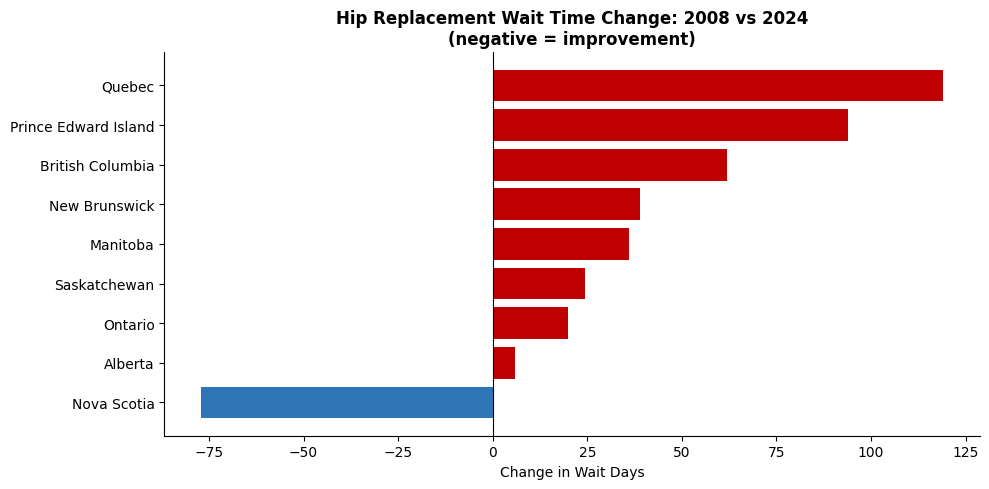

                      wait_2008  wait_2024  change_days  pct_change
province                                                           
Nova Scotia               201.0      124.0        -77.0       -38.3
Alberta                   103.0      109.0          6.0         5.8
Ontario                    63.0       83.0         20.0        31.7
Saskatchewan              157.0      181.5         24.5        15.6
Manitoba                  139.0      175.0         36.0        25.9
New Brunswick             140.0      179.0         39.0        27.9
British Columbia           71.0      133.0         62.0        87.3
Prince Edward Island      110.0      204.0         94.0        85.5
Quebec                     69.0      188.0        119.0       172.5


In [10]:
# ─────────────────────────────────────────────────────────────
# CIHI Wait Times: Hip Replacement Change from 2008 to 2024
# ─────────────────────────────────────────────────────────────
# In this section, I compare hip replacement median wait times between 2008 and 2024 for each province.
#
# The goal is to see which provinces improved over time and which provinces had longer wait times in 2024 compared with 2008.
#
# A negative change means the province improved because wait days decreased.
# A positive change means wait times increased compared with the 2008 baseline.


# ─────────────────────────────────────────────────────────────
# Create a Pivot Table
# ─────────────────────────────────────────────────────────────
# I keep only Hip Replacement records, then reshape the data so that:
#
# - each row represents one province
# - each column represents one year
# - each value represents the median wait days for that province and year
#

pivot = (
    cihi_plot[cihi_plot["indicator"] == "Hip Replacement"]
    .pivot_table(
        index="province",
        columns="data_year",
        values="indicator_result"
    )
)


# ─────────────────────────────────────────────────────────────
# Keep Provinces with Both 2008 and 2024 Data
# ─────────────────────────────────────────────────────────────
# Some provinces may not have values for both years.
# To make a fair comparison, I only keep provinces that have data in both 2008 and 2024.

change = pd.DataFrame({
    "wait_2008": pivot[2008],
    "wait_2024": pivot[2024],
}).dropna()


# ─────────────────────────────────────────────────────────────
# Calculate Change in Wait Days
# ─────────────────────────────────────────────────────────────
# change_days shows the absolute difference:
#
# wait_2024 - wait_2008
#
# If the value is negative, wait times decreased.
# If the value is positive, wait times increased.

change["change_days"] = change["wait_2024"] - change["wait_2008"]


# ─────────────────────────────────────────────────────────────
# Calculate Percentage Change
# ─────────────────────────────────────────────────────────────
# pct_change shows the size of the change relative to the 2008 value.
#
# This is useful because a 20-day increase may be more meaningful for a province that started at 60 days than for one that started at 200 days.

change["pct_change"] = (
    change["change_days"] / change["wait_2008"] * 100
).round(1)


# Sort from biggest improvement to biggest increase
change = change.sort_values("change_days")


# ─────────────────────────────────────────────────────────────
# Bar Chart: Change in Wait Days
# ─────────────────────────────────────────────────────────────
# I use a horizontal bar chart because province names are easier to read.
#
# Blue bars mean wait times decreased from 2008 to 2024.
# Red bars mean wait times increased from 2008 to 2024.

fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    "#2E75B6" if x < 0 else "#C00000"
    for x in change["change_days"]
]

ax.barh(
    change.index,
    change["change_days"],
    color=colors
)

# Add a zero reference line.
# Bars to the left of zero show improvement.
# Bars to the right of zero show increased wait times.
ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Hip Replacement Wait Time Change: 2008 vs 2024\n(negative = improvement)",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Change in Wait Days")

plt.tight_layout()
plt.show()



print(change[["wait_2008", "wait_2024", "change_days", "pct_change"]])

This chart compares median hip replacement wait times in 2008 and 2024 for each province. Negative values indicate improvement because wait times decreased, while positive values indicate longer wait times in 2024 compared with 2008.

Most provinces experienced an increase in median hip replacement wait times between 2008 and 2024. Quebec had the largest increase, rising from **69 days in 2008** to **188 days in 2024**, an increase of **119 days** or **172.5%**. Prince Edward Island and British Columbia also showed large increases, with wait times rising by **94 days** and **62 days**, respectively.

Nova Scotia was the only province that showed a clear improvement. Its median wait time decreased from **201 days in 2008** to **124 days in 2024**, a reduction of **77 days** or **38.3%**.

Alberta remained relatively stable, with only a small increase of **6 days** between 2008 and 2024.

Overall, the results suggest that long-term access to hip replacement procedures worsened in most provinces, while Nova Scotia improved substantially. However, this comparison only looks at the starting and ending years, so it should be interpreted alongside the full trend chart to understand year-to-year changes and the impact of the COVID period.